# Titanic End To End Data Preprocessing Pipleline

**Problem Statement**

Raw, real-world datasets are rarely clean or ready for machine learning. They often contain missing values, outliers, inconsistent formats, and unscaled features — all of which can significantly hurt model performance if not handled properly.
The goal of this project is to build an end-to-end, reusable data preprocessing pipeline using the Titanic dataset. Rather than doing one-off cleaning for a single project, the pipeline should be structured as a Python class that can accept any raw CSV and output a clean, model-ready DataFrame.

The pipeline will handle:

- Missing value imputation
- Outlier detection and treatment
- Categorical variable encoding
- Feature engineering
- Feature scaling and normalization

By the end, you will have a plug-and-play preprocessing tool that can be reused across future ML projects, saving time and ensuring consistency in data preparation.


### Step 1 - Load The Dataset

In [2]:
# import libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# load the data
df = pd.read_csv('train.csv')

In [4]:
# first look
print(df.shape)
print(df.head())
print(df.info())
print(df.describe())

(891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN    

### Step 2: Explore The Data

In [5]:
# check missing values
print(df.isnull().sum()) # count of missing values in each column
print((df.isnull().sum()/len(df))*100) # percentage of missing values in each column

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64


In [6]:
# check unique values in categorical columns
print(df['Sex'].value_counts())
print(df['Embarked'].value_counts())
print(df['Pclass'].value_counts())

Sex
male      577
female    314
Name: count, dtype: int64
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64
Pclass
3    491
1    216
2    184
Name: count, dtype: int64


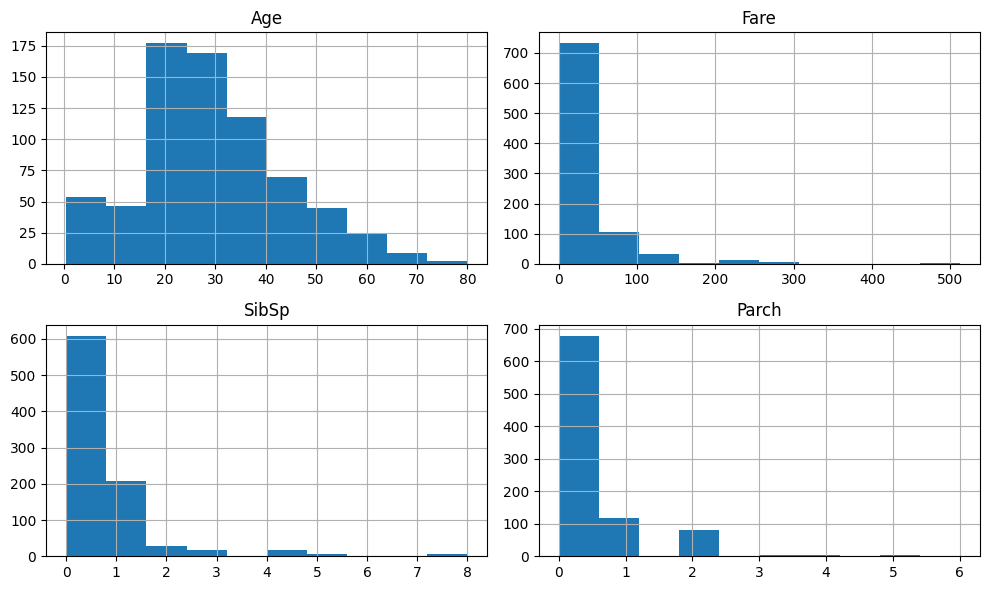

In [7]:
# look at the distribution of numerical columns
df[['Age', 'Fare', 'SibSp', 'Parch']].hist(figsize=(10,6))
plt.tight_layout()
plt.show()

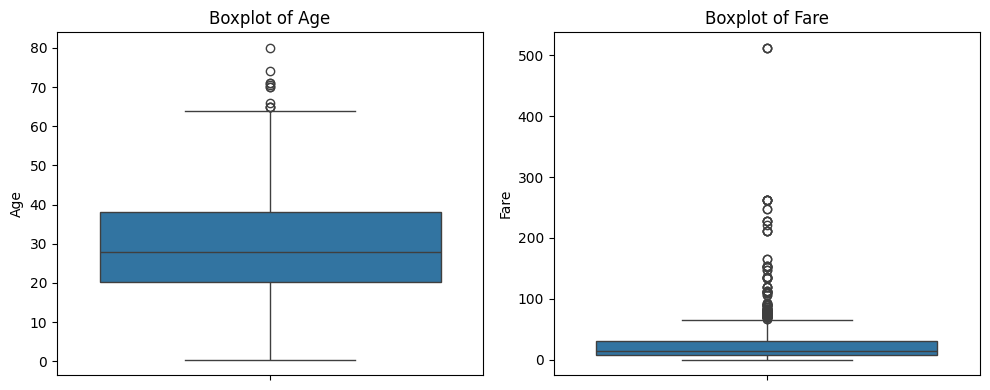

In [8]:
# check for outliers 
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.boxplot(y=df['Age'])
plt.title('Boxplot of Age')

plt.subplot(1,2,2)
sns.boxplot(y=df['Fare'])
plt.title('Boxplot of Fare')

plt.tight_layout()
plt.show()

In [9]:
# check survival rate against key columns 
print(df.groupby('Sex')['Survived'].mean())
print(df.groupby('Pclass')['Survived'].mean())
print(df.groupby('Embarked')['Survived'].mean())

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64
Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64


### Step 3: Handling Missing Values

In [10]:
# Reload fresh data
df = pd.read_csv('train.csv')

# Drop Cabin
df.drop(columns=['Cabin'], inplace=True)

# Fill missing Age with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing Embarked with mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop irrelevant columns
df.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)

In [11]:
# Verify
print(df.isnull().sum())

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


### Step 4: Outlier Detection And Treatment

Find extreme values that could skew your model and cap or remove them

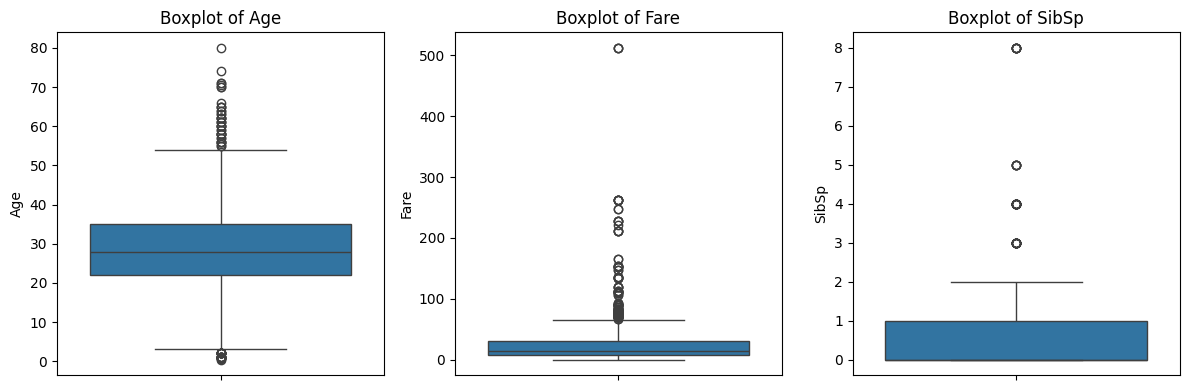

In [12]:
# visualize outliers with boxplots 
plt.figure(figsize=(12,4)) 

plt.subplot(1,3,1)
sns.boxplot(y=df['Age'])
plt.title('Boxplot of Age')

plt.subplot(1,3,2)
sns.boxplot(y=df['Fare'])
plt.title('Boxplot of Fare')

plt.subplot(1,3,3)
sns.boxplot(y=df['SibSp'])
plt.title('Boxplot of SibSp')

plt.tight_layout()
plt.show()

In [13]:
# Detect outliers using IQR method
# The IQR (Interquartile Range) method is the standard way to detect outliers mathematically. 

def detect_outliers_iqr(col):
    Q1 = col.quantile(0.25)
    Q3 = col.quantile(0.75)
    
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = col[(col < lower) | (col > upper)]
    print(f"Lower bound: {lower:.2f}, Upper bound: {upper:.2f}, Outliers found: {len(outliers)}")

detect_outliers_iqr(df['Age'])
detect_outliers_iqr(df['Fare'])
detect_outliers_iqr(df['SibSp'])

Lower bound: 2.50, Upper bound: 54.50, Outliers found: 66
Lower bound: -26.72, Upper bound: 65.63, Outliers found: 116
Lower bound: -1.50, Upper bound: 2.50, Outliers found: 46


In [14]:
# Cap the Outliers (Winsorization)
# Instead of deleting rows with outliers (which loses data), we cap them at the boundary values. This is called Winsorization.

def cap_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower, upper=upper)
    return df

df = cap_outliers(df, 'Age')
df = cap_outliers(df, 'Fare')
df = cap_outliers(df, 'SibSp')

Text(0.5, 1.0, 'SibSp (after capping)')

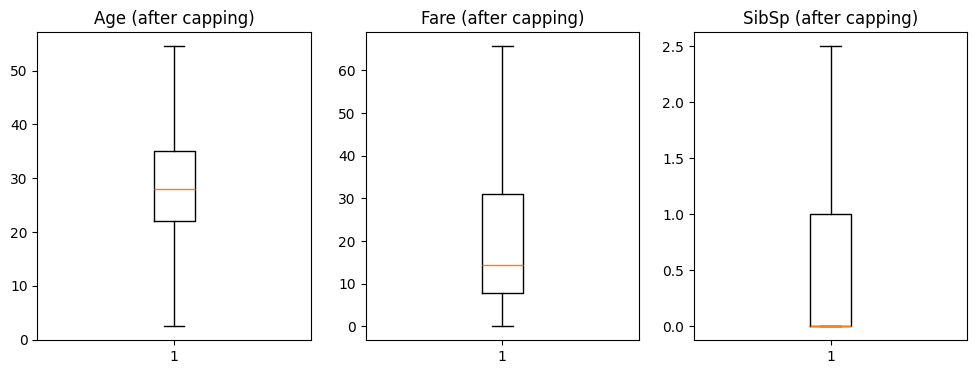

In [15]:
# Verify with boxplots again
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.boxplot(df['Age'])
plt.title('Age (after capping)')

plt.subplot(1,3,2)
plt.boxplot(df['Fare'])
plt.title('Fare (after capping)')

plt.subplot(1,3,3)
plt.boxplot(df['SibSp'])
plt.title('SibSp (after capping)')

### Step 5: Encoding Categorical Variables

**Goal:** Convert text/category columns into nunbers because ML models can only work with numbers

**We have two methods:**

- Label Encoding: use when we only have two categories
- One-Hot Encoding: use when we have 3+ categories

In [ ]:
# Label Encoding for categorical variables
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
# df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

In [20]:
# One Hot Encoding for Embarked
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

# drop_first=True drops one of the 3 columns to avoid multicollinearity (where one column can be predicted from the others).

In [21]:
print(df.head())
print(df.dtypes)
print(df.shape)

   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked_Q  Embarked_S
0         0       3    0  22.0    1.0      0   7.2500       False        True
1         1       1    1  38.0    1.0      0  65.6344       False       False
2         1       3    1  26.0    0.0      0   7.9250       False        True
3         1       1    1  35.0    1.0      0  53.1000       False        True
4         0       3    0  35.0    0.0      0   8.0500       False        True
Survived        int64
Pclass          int64
Sex             int64
Age           float64
SibSp         float64
Parch           int64
Fare          float64
Embarked_Q       bool
Embarked_S       bool
dtype: object
(891, 9)


### Step 6: Feature Engineering

**Goal:** Create new, more meaningful columns from existing ones to give your model better signals. 

**What will we create**

- FamilySize: total people travelling together 
- IsAlone: alone passengers had different survival rates 
- FarePerPerson: more accurate cost per individual

In [22]:
# Family Size 
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1 # +1 for the passenger themselves

In [23]:
# isAlone
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

In [24]:
# FarePerPerson
df['FarePerPerson'] = df['Fare'] / df['FamilySize']

In [25]:
# Verify the new columns
print(df[['SibSp', 'Parch', 'FamilySize', 'IsAlone', 'Fare', 'FarePerPerson']].head(10))

   SibSp  Parch  FamilySize  IsAlone     Fare  FarePerPerson
0    1.0      0         2.0        0   7.2500       3.625000
1    1.0      0         2.0        0  65.6344      32.817200
2    0.0      0         1.0        1   7.9250       7.925000
3    1.0      0         2.0        0  53.1000      26.550000
4    0.0      0         1.0        1   8.0500       8.050000
5    0.0      0         1.0        1   8.4583       8.458300
6    0.0      0         1.0        1  51.8625      51.862500
7    2.5      1         4.5        0  21.0750       4.683333
8    0.0      2         3.0        0  11.1333       3.711100
9    1.0      0         2.0        0  30.0708      15.035400


In [26]:
# Drop the original columns we no longer need
df.drop(columns=['SibSp', 'Parch'], inplace=True)

In [27]:
print(df.head())
print(df.shape)
print(df.dtypes)

   Survived  Pclass  Sex   Age     Fare  Embarked_Q  Embarked_S  FamilySize  \
0         0       3    0  22.0   7.2500       False        True         2.0   
1         1       1    1  38.0  65.6344       False       False         2.0   
2         1       3    1  26.0   7.9250       False        True         1.0   
3         1       1    1  35.0  53.1000       False        True         2.0   
4         0       3    0  35.0   8.0500       False        True         1.0   

   IsAlone  FarePerPerson  
0        0         3.6250  
1        0        32.8172  
2        1         7.9250  
3        0        26.5500  
4        1         8.0500  
(891, 10)
Survived           int64
Pclass             int64
Sex                int64
Age              float64
Fare             float64
Embarked_Q          bool
Embarked_S          bool
FamilySize       float64
IsAlone            int64
FarePerPerson    float64
dtype: object


### Step 7: Feature Scaling

**Goal:** Bring all numerical columns to the same scale so no single feature dominates the model just because of its size.

**Why do we need scaling?**

Without scaling, a column like Fare (values 0–500) will overpower Age (values 0–80) even if Age is more important. Scaling fixes this.

**Two Methods**

| Method | Formula | Output Range | When to Use |
|---|---|---|---|
| **StandardScaler** | (x - mean) / std | No fixed range, mean=0 | When data is normally distributed |
| **MinMaxScaler** | (x - min) / (max - min) | 0 to 1 | When data is skewed |

In [29]:
# import the scalers
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# apply standard scaling to Age
scaler_standard = StandardScaler()
df['Age'] = scaler_standard.fit_transform(df[['Age']])

# apply min-max scaling to Fare and FarePerPerson
scaler_minmax = MinMaxScaler()
df[['Fare', 'FarePerPerson']] = scaler_minmax.fit_transform(df[['Fare', 'FarePerPerson']])

# verify the scaling
print(df[['Age', 'Fare', 'FarePerPerson']].describe())

                Age        Fare  FarePerPerson
count  8.910000e+02  891.000000     891.000000
mean   2.392400e-17    0.366375       0.232230
std    1.000562e+00    0.312056       0.216927
min   -2.199638e+00    0.000000       0.000000
25%   -5.834321e-01    0.120522       0.116555
50%   -8.613809e-02    0.220223       0.131981
75%    4.940382e-01    0.472313       0.250696
max    2.110244e+00    1.000000       1.000000


In [31]:
print(df.head())
print(df.shape)
print(df.dtypes)

   Survived  Pclass  Sex       Age      Fare  Embarked_Q  Embarked_S  \
0         0       3    0 -0.583432  0.110460       False        True   
1         1       1    1  0.742685  1.000000       False       False   
2         1       3    1 -0.251903  0.120745       False        True   
3         1       1    1  0.494038  0.809027       False        True   
4         0       3    0  0.494038  0.122649       False        True   

   FamilySize  IsAlone  FarePerPerson  
0         2.0        0       0.055230  
1         2.0        0       0.500000  
2         1.0        1       0.120745  
3         2.0        0       0.404513  
4         1.0        1       0.122649  
(891, 10)
Survived           int64
Pclass             int64
Sex                int64
Age              float64
Fare             float64
Embarked_Q          bool
Embarked_S          bool
FamilySize       float64
IsAlone            int64
FarePerPerson    float64
dtype: object


### Step 8: Wrapping Into A Reusable Pipeline Class

In [32]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler

class DataPreprocessingPipeline:
    
    def __init__(self):
        self.scaler_standard = StandardScaler()
        self.scaler_minmax = MinMaxScaler()
    
    def load_data(self, filepath):
        self.df = pd.read_csv(filepath)
        print(f"Data loaded: {self.df.shape}")
        return self
    
    def handle_missing_values(self):
        # Drop Cabin - too many missing
        self.df.drop(columns=['Cabin'], inplace=True)
        
        # Fill Age with median
        self.df['Age'] = self.df['Age'].fillna(self.df['Age'].median())
        
        # Fill Embarked with mode
        self.df['Embarked'] = self.df['Embarked'].fillna(self.df['Embarked'].mode()[0])
        
        # Drop irrelevant columns
        self.df.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)
        
        print("Missing values handled ✅")
        return self
    
    def handle_outliers(self):
        def cap_outliers(df, col):
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR
            df[col] = df[col].clip(lower=lower, upper=upper)
            return df
        
        for col in ['Age', 'Fare', 'SibSp']:
            self.df = cap_outliers(self.df, col)
        
        print("Outliers handled ✅")
        return self
    
    def encode_categorical(self):
        # Label encode Sex
        self.df['Sex'] = self.df['Sex'].map({'male': 0, 'female': 1})
        
        # One-hot encode Embarked
        self.df = pd.get_dummies(self.df, columns=['Embarked'], drop_first=True)
        
        print("Categorical variables encoded ✅")
        return self
    
    def engineer_features(self):
        # Create new features
        self.df['FamilySize'] = self.df['SibSp'] + self.df['Parch'] + 1
        self.df['IsAlone'] = (self.df['FamilySize'] == 1).astype(int)
        self.df['FarePerPerson'] = self.df['Fare'] / self.df['FamilySize']
        
        # Drop original columns
        self.df.drop(columns=['SibSp', 'Parch'], inplace=True)
        
        print("Features engineered ✅")
        return self
    
    def scale_features(self):
        # StandardScaler for Age
        self.df['Age'] = self.scaler_standard.fit_transform(self.df[['Age']])
        
        # MinMaxScaler for Fare and FarePerPerson
        self.df[['Fare', 'FarePerPerson']] = self.scaler_minmax.fit_transform(
            self.df[['Fare', 'FarePerPerson']]
        )
        
        print("Features scaled ✅")
        return self
    
    def fit_transform(self, filepath):
        return (self
                .load_data(filepath)
                .handle_missing_values()
                .handle_outliers()
                .encode_categorical()
                .engineer_features()
                .scale_features()
                .df)

pipeline = DataPreprocessingPipeline()
clean_df = pipeline.fit_transform('train.csv')

print(clean_df.head())
print(clean_df.shape)
print(clean_df.isnull().sum())

Data loaded: (891, 12)
Missing values handled ✅
Outliers handled ✅
Categorical variables encoded ✅
Features engineered ✅
Features scaled ✅
   Survived  Pclass  Sex       Age      Fare  Embarked_Q  Embarked_S  \
0         0       3    0 -0.583432  0.110460       False        True   
1         1       1    1  0.742685  1.000000       False       False   
2         1       3    1 -0.251903  0.120745       False        True   
3         1       1    1  0.494038  0.809027       False        True   
4         0       3    0  0.494038  0.122649       False        True   

   FamilySize  IsAlone  FarePerPerson  
0         2.0        0       0.055230  
1         2.0        0       0.500000  
2         1.0        1       0.120745  
3         2.0        0       0.404513  
4         1.0        1       0.122649  
(891, 10)
Survived         0
Pclass           0
Sex              0
Age              0
Fare             0
Embarked_Q       0
Embarked_S       0
FamilySize       0
IsAlone          0
FarePer